# Stage 3:完整荷載組合 + Demand Extraction + 構件分組

延伸 [Stage 2](stage2_canonical_elastic_model.ipynb) 已驗證過的 canonical
elastic model(真梁真柱+規範勁度折減,OpenSeesPy/PyNite雙工具交叉驗證過),
這一課做三件事:

1. **重新推導重力載重**(不再用 Case-03.6 反推的暫用值),改用真實的
   跨度/柱列間距(見 Case-04 的 X向3跨18m/Y向4榀構架)+
   `結構計算書-基本款.md` 的真實樓板/材料單位重量,算出有憑有據的
   D(靜載重)、L(活載重)
2. **套完整6組合荷載組合**(`結構計算書-基本款.md` 第4C節,H/Ez項對
   這個簡化2D單榀模型不適用,設為0)
3. **Demand extraction + 構件分組**:每個構件、每個組合都留下
   governing load combination 的記錄(不是把不同工況的最大值硬湊成
   一個不存在的組合——見 HANDOFF.md 的提醒),1F柱組/2F柱組取L/R柱
   envelope

最後接上 Case-08 系列已驗證過的設計函式(`design_rebar`/
`design_column_PM`/`design_stirrups`),對 governing demand 跑一次
**Stage 4 的搶先預覽**——嚴格說 Stage 3 本身不含配筋設計,這是把
Stage 4 提前接上去,順便把配筋圖畫出來給你看,不是 Stage 3 正式產出。

In [1]:
import numpy as np

try:
    import openseespy.opensees as ops  # noqa: F401
except ImportError:
    import sys
    !{sys.executable} -m pip install -q "numpy<2.5" openseespy
    import openseespy.opensees as ops  # noqa: F401

L = 6.0
h1 = h2 = 3.5
E_rc = 2.463e7          # kN/m^2, 沿用Case-03.5/case03_7
h_col = 0.40             # m, 柱 40x40cm trial section
b_beam, h_beam = 0.30, 0.50   # m, 梁 30x50cm trial section

Ig_col = h_col**4/12
Ig_beam = b_beam*h_beam**3/12
A_col = h_col**2
A_beam = b_beam*h_beam
RF_COL, RF_BEAM = 0.70, 0.35
I_col_eff = RF_COL * Ig_col
I_beam_eff = RF_BEAM * Ig_beam

print(f"柱 {h_col*100:.0f}x{h_col*100:.0f}cm  0.7Ig={I_col_eff:.6f} m^4")
print(f"梁 {b_beam*100:.0f}x{h_beam*100:.0f}cm  0.35Ig={I_beam_eff:.6f} m^4")

柱 40x40cm  0.7Ig=0.001493 m^4
梁 30x50cm  0.35Ig=0.001094 m^4


## 重新推導 D(靜載重)/L(活載重)

Stage 2 用的 w=49.2kN/m 是從 Case-03.6 已建立的柱軸力反推回來的暫用值,
沒有拆分 D/L,也沒有真正的傳力面積依據。這一課改用真實幾何+
`結構計算書-基本款.md` 的真實單位重量重新算:

- **從屬寬度**:桃園案例(Case-04)是 X向3跨(18m,4根柱列)、Y向4榀構架
  平行分攤,這一榀 Y向構架的從屬寬度 = 18m/4榀 = 4.5m(跟 Case-04.5
  分配側向力用的除數一致,gravity 用同一個除法邏輯)
- **樓板自重**:15cm RC 樓板 × 2400kg/m³(`結構計算書-基本款.md`
  第5節 ETABS 輸入資料,混凝土單位重)= 360 kg/m²
- **樓板粉刷/裝修**:100 kg/m²(`結構計算書-基本款.md`
  「一般區域:高架地板55+樓版雙面粉光40+管線5=100kg/m²」)
- **梁自重**:30×50cm × 2400kg/m³,沿梁本身長度分佈
- **柱自重**:40×40cm × 2400kg/m³,沿柱本身長度分佈,只隨 D 係數縮放
- **活載重**:300 kg/m²(`結構計算書-基本款.md`「二～三層:住宅」)——
  這一課的2層測試構架沒有明確對應到文件裡的哪一個實際樓層,兩層都先
  用同一個一般住宅活載重值,不刻意套用文件裡1F=500kg/m²的較高值
  (那個較高值文件裡沒說明原因,可能對應可彈性使用的空間,不確定,
  不要沒理解就套用)

In [2]:
X_total = 18.0            # m, Case-04 X向3跨總長
n_frames_Y = 4              # Case-04.5 Y向4榀平行構架
trib_width = X_total/n_frames_Y   # 4.5 m

gamma_conc = 2400.0         # kg/m^3, 結構計算書-基本款.md 第5節
t_slab = 0.15                # m, 結構計算書-基本款.md 版尺寸
D_finish = 100.0             # kg/m^2, 結構計算書-基本款.md 一般區域
L_area = 300.0               # kg/m^2, 結構計算書-基本款.md 二~三層住宅

D_area = t_slab*gamma_conc + D_finish
D_beam_self_kgf_m = b_beam*h_beam*gamma_conc

kgf_to_kN = 9.80665e-3
D_udl = (D_area*trib_width + D_beam_self_kgf_m)*kgf_to_kN
L_udl = (L_area*trib_width)*kgf_to_kN
col_self_kN_m = (h_col*h_col*gamma_conc)*kgf_to_kN

print(f"從屬寬度 = {trib_width} m")
print(f"D_area(樓板自重+粉刷) = {D_area:.0f} kg/m^2")
print(f"D_udl(樓板+梁自重) = {D_udl:.3f} kN/m")
print(f"L_udl = {L_udl:.3f} kN/m")
print(f"D+L = {D_udl+L_udl:.3f} kN/m")
print(f"柱自重(沿柱軸向) = {col_self_kN_m:.3f} kN/m")
print()
print(f"[對照] Stage 2 用的暫用值 w=49.2 kN/m, 這一課重新算出 D+L="
      f"{D_udl+L_udl:.2f} kN/m, 差了 {(1-(D_udl+L_udl)/49.2):.1%}")
print("[開放項目] 這個落差沒有回頭改Stage2用掉的49.2(那一課的重點是")
print("驗模型/驗solver, 不是驗荷重), 但這裡如實記錄, 不掩蓋——Stage2的")
print("49.2是從更早的Case-03.6概估值反推, 可能含牆重或不同活載重假設,")
print("沒有繼續往回查證到底(Case-03.6本身也沒有詳列每一項怎麼來的),")
print("這一課的37.07才是第一次有完整、可追溯依據的算法。")

從屬寬度 = 4.5 m
D_area(樓板自重+粉刷) = 460 kg/m^2
D_udl(樓板+梁自重) = 23.830 kN/m
L_udl = 13.239 kN/m
D+L = 37.069 kN/m
柱自重(沿柱軸向) = 3.766 kN/m

[對照] Stage 2 用的暫用值 w=49.2 kN/m, 這一課重新算出 D+L=37.07 kN/m, 差了 24.7%
[開放項目] 這個落差沒有回頭改Stage2用掉的49.2(那一課的重點是
驗模型/驗solver, 不是驗荷重), 但這裡如實記錄, 不掩蓋——Stage2的
49.2是從更早的Case-03.6概估值反推, 可能含牆重或不同活載重假設,
沒有繼續往回查證到底(Case-03.6本身也沒有詳列每一項怎麼來的),
這一課的37.07才是第一次有完整、可追溯依據的算法。


## 荷載組合(`結構計算書-基本款.md` 第4C節)

原文 6 組合含 H(側向土壓)跟 Ez(垂直地震力),這個簡化2D單榀模型
沒有基礎土壓、也沒有做垂直地震力分量,兩者都設為0,組合2/3跟4/5在
Ez=0時退化成同一對(僅正負號差異),實際跑5個獨立案例:

In [3]:
F1_frame, F2_frame = 9.938, 15.900   # kN, Y向單榀地震力(Case-03.5)

COMBOS = [
    ("C1: 1.4D+1.7L",       1.4,  1.7,  0.0),
    ("C2: 1.05D+1.403Ex",   1.05, 0.0, +1.403),
    ("C3: 1.05D-1.403Ex",   1.05, 0.0, -1.403),
    ("C4: 0.9D+1.40Ex",     0.9,  0.0, +1.40),
    ("C5: 0.9D-1.40Ex",     0.9,  0.0, -1.40),
    ("C6: 0.9D",            0.9,  0.0,  0.0),
]
for name, Df, Lf, Ef in COMBOS:
    print(f"{name:<22} D係數={Df}  L係數={Lf}  Ex係數={Ef}")

C1: 1.4D+1.7L          D係數=1.4  L係數=1.7  Ex係數=0.0
C2: 1.05D+1.403Ex      D係數=1.05  L係數=0.0  Ex係數=1.403
C3: 1.05D-1.403Ex      D係數=1.05  L係數=0.0  Ex係數=-1.403
C4: 0.9D+1.40Ex        D係數=0.9  L係數=0.0  Ex係數=1.4
C5: 0.9D-1.40Ex        D係數=0.9  L係數=0.0  Ex係數=-1.4
C6: 0.9D               D係數=0.9  L係數=0.0  Ex係數=0.0


## 建模與分析

沿用 Stage 2 的真梁真柱建模方法,梁多拆一個中跨節點(直接查中跨彎矩,
不手算彎矩方程式,跟這個 repo 一貫「別手算,讓 solver 自己算」的精神
一致)。

In [4]:
def extract_NVM(ele_id, vertical):
    """依構件方向, 把 ops.eleForce() 回傳的全域[Fx,Fy,Mz]分量投影成(N,V,M)。
    柱(垂直構件): N沿全域y, V沿全域x。梁(水平構件): N沿全域x, V沿全域y。
    (見Stage 2開發記錄)"""
    f = ops.eleForce(ele_id)
    if vertical:
        return dict(Ni=f[1], Vi=f[0], Mi=f[2], Nj=f[4], Vj=f[3], Mj=f[5])
    else:
        return dict(Ni=f[0], Vi=f[1], Mi=f[2], Nj=f[3], Vj=f[4], Mj=f[5])


def run_combo(Df, Lf, Ef):
    w = Df*D_udl + Lf*L_udl
    F1, F2 = Ef*F1_frame, Ef*F2_frame
    w_col = Df*col_self_kN_m   # 柱自重只隨D縮放(不是活載重)

    ops.wipe()
    ops.model('basic', '-ndm', 2, '-ndf', 3)
    ops.node(1, 0.0, 0.0); ops.node(2, L, 0.0)
    ops.node(3, 0.0, h1);  ops.node(4, L, h1)
    ops.node(5, 0.0, h1+h2); ops.node(6, L, h1+h2)
    ops.node(7, L/2, h1)          # 1F梁中跨節點(查中跨彎矩用)
    ops.node(8, L/2, h1+h2)       # 屋頂梁中跨節點
    ops.fix(1,1,1,1); ops.fix(2,1,1,1)
    ops.geomTransf('Linear', 1)
    ops.element('elasticBeamColumn', 1, 1, 3, A_col, E_rc, I_col_eff, 1)
    ops.element('elasticBeamColumn', 2, 2, 4, A_col, E_rc, I_col_eff, 1)
    ops.element('elasticBeamColumn', 3, 3, 5, A_col, E_rc, I_col_eff, 1)
    ops.element('elasticBeamColumn', 4, 4, 6, A_col, E_rc, I_col_eff, 1)
    ops.element('elasticBeamColumn', 5, 3, 7, A_beam, E_rc, I_beam_eff, 1)
    ops.element('elasticBeamColumn', 6, 7, 4, A_beam, E_rc, I_beam_eff, 1)
    ops.element('elasticBeamColumn', 7, 5, 8, A_beam, E_rc, I_beam_eff, 1)
    ops.element('elasticBeamColumn', 8, 8, 6, A_beam, E_rc, I_beam_eff, 1)

    ops.timeSeries('Linear', 1); ops.pattern('Plain', 1, 1)
    if F1: ops.load(3, F1, 0.0, 0.0)
    if F2: ops.load(5, F2, 0.0, 0.0)
    if w:
        for eid in [5,6,7,8]:
            ops.eleLoad('-ele', eid, '-type', '-beamUniform', -w)
    if w_col:
        for eid in [1,2,3,4]:
            ops.eleLoad('-ele', eid, '-type', '-beamUniform', 0.0, -w_col)

    ops.system('BandGeneral'); ops.numberer('RCM'); ops.constraints('Transformation')
    ops.test('NormDispIncr', 1e-10, 30); ops.algorithm('Newton')
    ops.integrator('LoadControl', 1.0); ops.analysis('Static')
    assert ops.analyze(1) == 0, "未收斂"
    ops.reactions()

    return dict(
        col1F_L=extract_NVM(1, True), col1F_R=extract_NVM(2, True),
        col2F_L=extract_NVM(3, True), col2F_R=extract_NVM(4, True),
        beam1F=extract_NVM(5, False), beam1F_mid_M=ops.eleForce(6)[2],
        beamRF=extract_NVM(7, False), beamRF_mid_M=ops.eleForce(8)[2],
    )


records = []
for name, Df, Lf, Ef in COMBOS:
    r = run_combo(Df, Lf, Ef)
    for member in ['col1F_L','col1F_R','col2F_L','col2F_R','beam1F','beamRF']:
        f = r[member]
        rec = dict(combo=name.split(':')[0], member=member, Df=Df, Lf=Lf, Ef=Ef, **f)
        records.append(rec)
    records.append(dict(combo=name.split(':')[0], member='beam1F_mid', M=r['beam1F_mid_M']))
    records.append(dict(combo=name.split(':')[0], member='beamRF_mid', M=r['beamRF_mid_M']))

print(f"共 {len(COMBOS)} 組合 x 6構件(+2個中跨查詢點) = {len(records)} 筆記錄")

共 6 組合 x 6構件(+2個中跨查詢點) = 48 筆記錄


## Demand Extraction + Governing Combination 追溯

每一個構件、每一個端點,N/V/M 各自找「哪一組荷載組合讓它絕對值最大」,
連 combo 名字一起記錄下來,不是把不同工況的最大值硬湊成一個不存在的
組合。

In [5]:
from collections import defaultdict

by_member = defaultdict(list)
for rec in records:
    if 'combo' in rec and 'Ni' in rec:
        by_member[rec['member']].append(rec)

def governing(recs):
    best = {}
    for end, (kN, kV, kM) in [('i', ('Ni','Vi','Mi')), ('j', ('Nj','Vj','Mj'))]:
        for key, label in [(kN,'N'), (kV,'V'), (kM,'M')]:
            gov = max(recs, key=lambda r: abs(r[key]))
            best[f'{label}_{end}'] = (gov[key], gov['combo'])
    return best

print(f"{'構件':<10}{'量':<6}{'govern值':>12}{'combo':>10}")
governing_table = {}
for member, recs in by_member.items():
    g = governing(recs)
    governing_table[member] = g
    for k, (val, combo) in g.items():
        print(f"{member:<10}{k:<6}{val:>12.3f}{combo:>10}")

構件        量          govern值     combo
col1F_L   N_i        372.115        C1
col1F_L   V_i         27.792        C3
col1F_L   M_i        -56.432        C3
col1F_L   N_j       -353.663        C1
col1F_L   V_j        -27.792        C3
col1F_L   M_j        -49.972        C1
col1F_R   N_i        372.115        C1
col1F_R   V_i        -27.735        C2
col1F_R   M_i         56.298        C2
col1F_R   N_j       -353.663        C1
col1F_R   V_j         27.735        C2
col1F_R   M_j         49.972        C1
col2F_L   N_i        186.058        C1
col2F_L   V_i         71.211        C1
col2F_L   M_i       -107.113        C1
col2F_L   N_j       -167.605        C1
col2F_L   V_j        -71.211        C1
col2F_L   M_j       -142.126        C1
col2F_R   N_i        186.058        C1
col2F_R   V_i        -71.211        C1
col2F_R   M_i        107.113        C1
col2F_R   N_j       -167.605        C1
col2F_R   V_j         71.211        C1
col2F_R   M_j        142.126        C1
beam1F    N_i        -49.

## 構件分組

這個構架只有 1 跨 2 柱,對稱幾何——重力組合(C1/C6)下 L/R 柱理論上
對稱,但地震力組合(C2~C5)會讓 L/R 不對稱(推向哪一邊,哪一邊的柱
demand 較大)。分組取 L+R 的 envelope(包絡),不分別設計兩根柱——
這是實務上合理的簡化(對稱構架的兩根柱通常配同一種筋,不會因為推力
方向不同就設計成不同柱)。

In [6]:
def envelope_group(members):
    all_recs = []
    for m in members:
        all_recs.extend(by_member[m])
    return governing(all_recs)

group_1F_col = envelope_group(['col1F_L','col1F_R'])
group_2F_col = envelope_group(['col2F_L','col2F_R'])

print("--- 1F柱組(L+R envelope) ---")
for k,(val,combo) in group_1F_col.items():
    print(f"  {k}: {val:.3f} ({combo})")
print("--- 2F柱組(L+R envelope) ---")
for k,(val,combo) in group_2F_col.items():
    print(f"  {k}: {val:.3f} ({combo})")

--- 1F柱組(L+R envelope) ---
  N_i: 372.115 (C1)
  V_i: 27.792 (C3)
  M_i: -56.432 (C3)
  N_j: -353.663 (C1)
  V_j: -27.792 (C3)
  M_j: -49.972 (C1)
--- 2F柱組(L+R envelope) ---
  N_i: 186.058 (C1)
  V_i: -71.211 (C1)
  M_i: -107.113 (C1)
  N_j: -167.605 (C1)
  V_j: 71.211 (C1)
  M_j: 142.126 (C1)


## 構架幾何圖(2D 立面 + 3D 建築脈絡)

左圖:這一榀 Y向構架本身(這一課分析的對象),標尺寸跟節點編號。
右圖:這一榀構架在完整桃園案例(Case-04, X向3跨18m×Y向4榀6m)裡的
位置——這裡分析的是圖中反白那一榀。

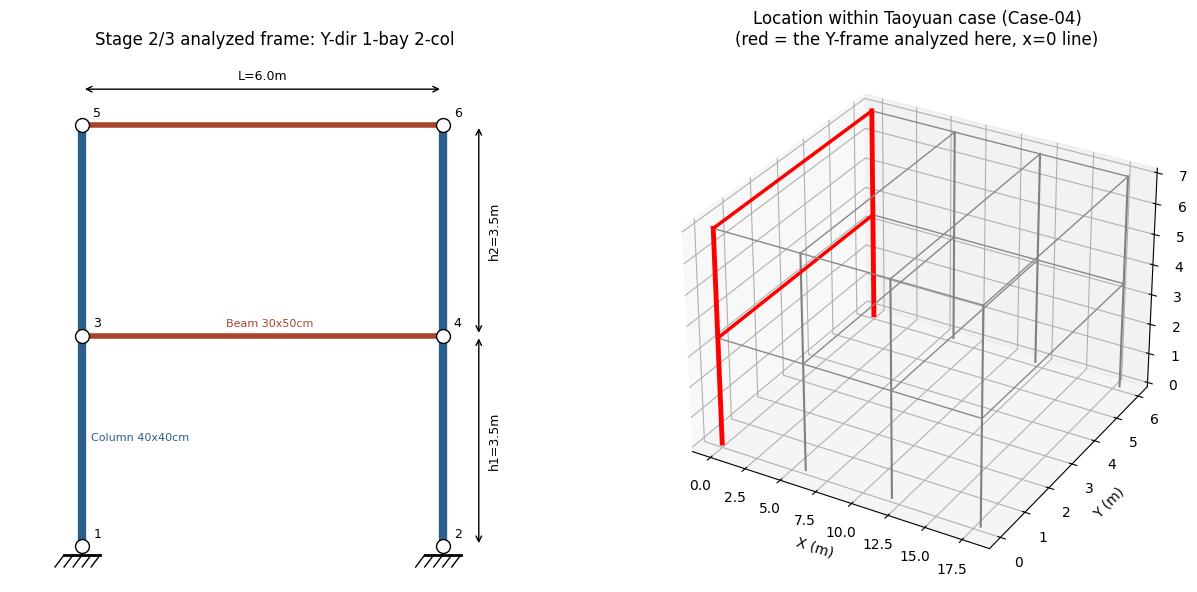

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(13, 6))

# ---- 左圖: 2D立面 ----
ax1 = fig.add_subplot(121)
nodes_2d = {1:(0,0), 2:(L,0), 3:(0,h1), 4:(L,h1), 5:(0,h1+h2), 6:(L,h1+h2)}
members_2d = [(1,3,'col'), (2,4,'col'), (3,5,'col'), (4,6,'col'),
              (3,4,'beam'), (5,6,'beam')]
for i,j,kind in members_2d:
    x = [nodes_2d[i][0], nodes_2d[j][0]]
    y = [nodes_2d[i][1], nodes_2d[j][1]]
    lw = 6 if kind=='col' else 4
    color = '#2c5f8a' if kind=='col' else '#a8452c'
    ax1.plot(x, y, '-', lw=lw, color=color, solid_capstyle='butt', zorder=2)
for nid,(x,y) in nodes_2d.items():
    ax1.plot(x, y, 'o', color='white', mec='black', ms=10, zorder=3)
    ax1.annotate(str(nid), (x,y), textcoords="offset points", xytext=(8,6), fontsize=9)
# 基礎符號
for x in [0, L]:
    ax1.plot([x-0.3, x+0.3], [-0.15, -0.15], 'k-', lw=2)
    for hx in np.linspace(x-0.3, x+0.3, 5):
        ax1.plot([hx, hx-0.15], [-0.15, -0.35], 'k-', lw=1)
ax1.annotate('', xy=(L+0.6, 0), xytext=(L+0.6, h1),
             arrowprops=dict(arrowstyle='<->'))
ax1.text(L+0.75, h1/2, f'h1={h1}m', rotation=90, va='center', fontsize=9)
ax1.annotate('', xy=(L+0.6, h1), xytext=(L+0.6, h1+h2),
             arrowprops=dict(arrowstyle='<->'))
ax1.text(L+0.75, h1+h2/2, f'h2={h2}m', rotation=90, va='center', fontsize=9)
ax1.annotate('', xy=(0, h1+h2+0.6), xytext=(L, h1+h2+0.6),
             arrowprops=dict(arrowstyle='<->'))
ax1.text(L/2, h1+h2+0.75, f'L={L}m', ha='center', fontsize=9)
ax1.text(0.15, h1/2, f'Column {h_col*100:.0f}x{h_col*100:.0f}cm', fontsize=8, color='#2c5f8a')
ax1.text(L/2-0.6, h1+0.15, f'Beam {b_beam*100:.0f}x{h_beam*100:.0f}cm', fontsize=8, color='#a8452c')
ax1.set_xlim(-1.2, L+1.6); ax1.set_ylim(-0.6, h1+h2+1.2)
ax1.set_aspect('equal'); ax1.axis('off')
ax1.set_title('Stage 2/3 analyzed frame: Y-dir 1-bay 2-col')

# ---- 右圖: 3D建築脈絡(桃園案例, Case-04幾何) ----
ax2 = fig.add_subplot(122, projection='3d')
xs_grid = [0.0, 6.0, 12.0, 18.0]
ys_grid = [0.0, 6.0]
zs_grid = [0.0, h1, h1+h2]
analyzed_x = 0.0   # 這一課分析的是x=0這一榀

for x in xs_grid:
    for y in ys_grid:
        color = 'red' if x==analyzed_x else 'gray'
        lw = 3.5 if x==analyzed_x else 1.5
        ax2.plot([x,x],[y,y],[0,h1+h2], '-', color=color, lw=lw)
for z in [h1, h1+h2]:
    for y in ys_grid:
        color = 'red' if analyzed_x in [0.0] else 'gray'
        ax2.plot(xs_grid, [y]*4, [z]*4, '-', color='#888888', lw=1)
    for x in xs_grid:
        color = 'red' if x==analyzed_x else '#888888'
        lw = 2.5 if x==analyzed_x else 1
        ax2.plot([x,x], ys_grid, [z,z], '-', color=color, lw=lw)
ax2.set_title('Location within Taoyuan case (Case-04)\n(red = the Y-frame analyzed here, x=0 line)')
ax2.set_xlabel('X (m)'); ax2.set_ylabel('Y (m)'); ax2.set_zlabel('Z (m)')

plt.tight_layout()
plt.show()

## Stage 4 預覽:用 governing demand 跑一次真正的設計

**這不是 Stage 3 正式產出**——Stage 3 的範圍到「demand extraction +
分組」為止。但既有 Case-08 系列的設計函式已經驗證過(VL-08/11/13),
把它們接上這裡算出來的 governing demand,順便先看一次配筋結果跟圖,
對確認整條主線走不走得通很有幫助。

正式的 Stage 4(含強柱弱梁檢核、剪力設計的塑鉸機制修正)還沒做,
這裡只是先用現成函式跑一次撓曲設計。

In [8]:
try:
    from rc_design import design_rebar, design_column_PM, design_stirrups
except ImportError:
    import sys
    !wget -q -O rc_design.py https://raw.githubusercontent.com/zhixiu0223/taiwan-seismic-code-calc/main/rc_design.py
    from rc_design import design_rebar, design_column_PM, design_stirrups

# ---- 柱設計檢核: 對每一個(combo, end)算utilization, 取最差的當governing ----
# (不是分別取N的最大值/M的最大值硬湊, 是逐一組合檢核phi-PM包絡線,
#  取真正最不利的那一組——見HANDOFF.md的提醒)
b_cm = h_cm = h_col*100
cover_to_center = 4.0 + 0.95 + 1.4/2   # cover+箍筋+主筋半徑(假設#11試排)
rho_trial = 0.02                        # 沿用Case-06/VL系列的試排配筋率
As_total_trial = rho_trial*b_cm*h_cm
As_bar = As_total_trial/8
As_layers = [3*As_bar, 2*As_bar, 3*As_bar]

def find_governing_column_demand(members):
    worst = None
    for member in members:
        for rec in by_member[member]:
            for end, sign in [('i', +1), ('j', -1)]:
                # Nj在元素座標系跟Ni反號(元素內部力平衡的慣例, 不是
                # 物理上真的變成拉力), 乘sign轉回"受壓為正"的物理量
                Pu, Mu = sign*rec[f'N{end}'], abs(rec[f'M{end}'])
                res = design_column_PM(b_cm=b_cm, h_cm=h_cm, As_per_layer_cm2=As_layers,
                                         cover_to_center_cm=cover_to_center, n_layers=3,
                                         fc=280.0, fy=4200.0, Pu_kN=Pu, Mu_kNm=Mu)
                if worst is None or res['utilization'] > worst[0]:
                    worst = (res['utilization'], rec['combo'], member, end, Pu, Mu, res)
    return worst

util, combo, member, end, Pu, Mu, res_col = find_governing_column_demand(['col1F_L','col1F_R'])
print(f"1F柱組 governing demand: combo={combo}, {member}-{end}端")
print(f"  Pu={Pu:.2f}kN(壓), Mu={Mu:.2f}kN-m, ρ_trial={rho_trial}")
print(f"  utilization={util:.1%}, within_envelope={res_col['within_envelope']}")

1F柱組 governing demand: combo=C1, col1F_L-j端
  Pu=353.66kN(壓), Mu=49.97kN-m, ρ_trial=0.02
  utilization=25.5%, within_envelope=True


In [9]:
# ---- 1F梁設計: 頂部(負彎矩, 端點governing) + 底部(正彎矩, 中跨代表值) ----
Mu_neg = governing_table['beam1F']['M_i'][0]
mid_recs = [r for r in records if r.get('member')=='beam1F_mid']
Mu_pos = max(abs(r['M']) for r in mid_recs)
Vu_beam = governing_table['beam1F']['V_i'][0]

b_beam_cm, h_beam_cm = b_beam*100, h_beam*100

res_top = design_rebar(abs(Mu_neg), b_beam_cm, h_beam_cm, fc=280.0, fy=4200.0)
res_bot = design_rebar(Mu_pos, b_beam_cm, h_beam_cm, fc=280.0, fy=4200.0)
res_shear = design_stirrups(abs(Vu_beam), b_beam_cm, res_top['d'], fc=280.0, fyv=2800.0)

print(f"1F梁 頂部(負彎矩={abs(Mu_neg):.2f}kN-m): {res_top['n_bars']}-{res_top['bar_size']}, "
      f"As={res_top['As_provided']:.2f}cm^2, phiMn={res_top['phiMn_provided']:.2f}kN-m, "
      f"利用率={abs(Mu_neg)/res_top['phiMn_provided']:.1%}")
print(f"1F梁 底部(正彎矩={Mu_pos:.2f}kN-m): {res_bot['n_bars']}-{res_bot['bar_size']}, "
      f"As={res_bot['As_provided']:.2f}cm^2, phiMn={res_bot['phiMn_provided']:.2f}kN-m, "
      f"利用率={Mu_pos/res_bot['phiMn_provided']:.1%}")
print(f"底/頂鋼筋比={res_bot['As_provided']/res_top['As_provided']:.1%} "
      f"({'滿足' if res_bot['As_provided']/res_top['As_provided']>=0.5 else '不滿足'}"
      f" 抗震慣例 >=50%)")
print(f"1F梁箍筋(Vu={abs(Vu_beam):.2f}kN): {res_shear['bar_size']}, "
      f"間距={res_shear['spacing_cm']}cm, phiVn={res_shear['phiVn']:.2f}kN, "
      f"ok={res_shear['ok']}")

1F梁 頂部(負彎矩=157.09kN-m): 4-#6(D19), As=11.46cm^2, phiMn=171.75kN-m, 利用率=91.5%
1F梁 底部(正彎矩=94.32kN-m): 2-#7(D22), As=7.74cm^2, phiMn=119.17kN-m, 利用率=79.2%
底/頂鋼筋比=67.6% (滿足 抗震慣例 >=50%)
1F梁箍筋(Vu=167.61kN): #4(D13), 間距=20cm, phiVn=200.00kN, ok=True


## 配筋圖

**梁**:分別畫頂部(負彎矩,端點)跟底部(正彎矩,中跨)兩張配筋圖——
真實梁是同時有頂部+底部鋼筋,這裡分開畫是為了讓每一張圖對應到單一
明確的設計需求,不是這根梁真的只有單面配筋。

**柱**:沿用 Case-08.4 已建立的慣例,用 P-M interaction 圖,把
governing demand 點標在圖上,而不是畫斷面配筋圖(柱的配筋是「先假設
對稱配置,檢查是否落在包絡線內」,不是像梁一樣「給Mu反推鋼筋量」)。

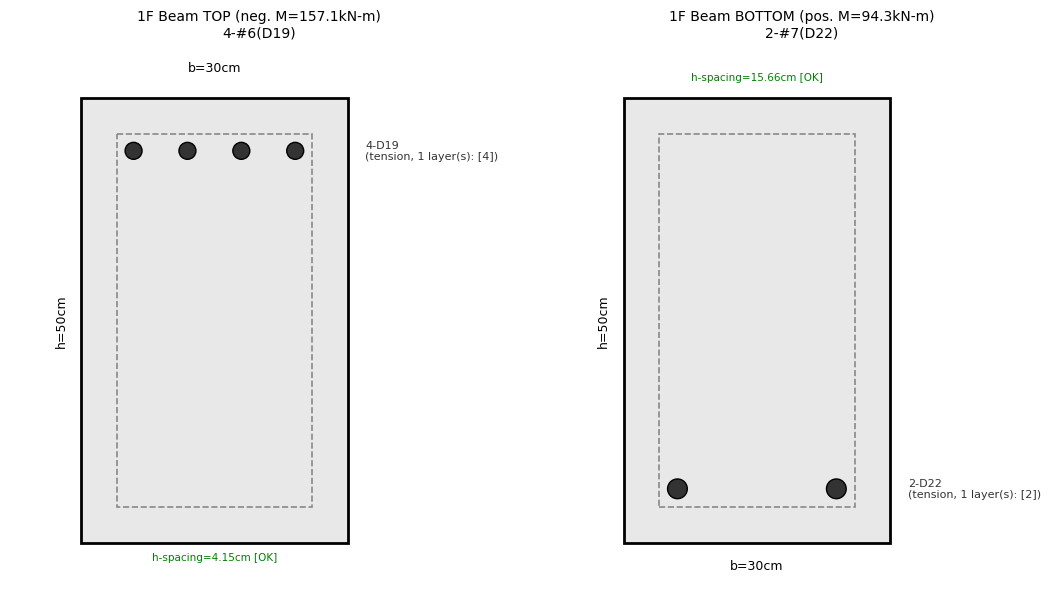

In [10]:
from rc_design import draw_rc_section

fig, axes = plt.subplots(1, 2, figsize=(11, 6))
draw_rc_section(b_beam_cm, h_beam_cm, cover_cm=4.0, layout=res_top['layout'],
                 bar_diameter_cm=res_top['bar_d'],
                 title=f"1F Beam TOP (neg. M={abs(Mu_neg):.1f}kN-m)\n{res_top['n_bars']}-{res_top['bar_size']}",
                 ax=axes[0])
# draw_rc_section()預設把主筋畫在斷面下緣(單筋梁正彎矩的標準畫法)。
# 頂部鋼筋(負彎矩/hogging)物理上在斷面上緣, 用invert_yaxis()把圖上下
# 翻轉, 讓畫面對應真實位置, 不是誤植
axes[0].invert_yaxis()
draw_rc_section(b_beam_cm, h_beam_cm, cover_cm=4.0, layout=res_bot['layout'],
                 bar_diameter_cm=res_bot['bar_d'],
                 title=f"1F Beam BOTTOM (pos. M={Mu_pos:.1f}kN-m)\n{res_bot['n_bars']}-{res_bot['bar_size']}",
                 ax=axes[1])
plt.tight_layout()
plt.show()

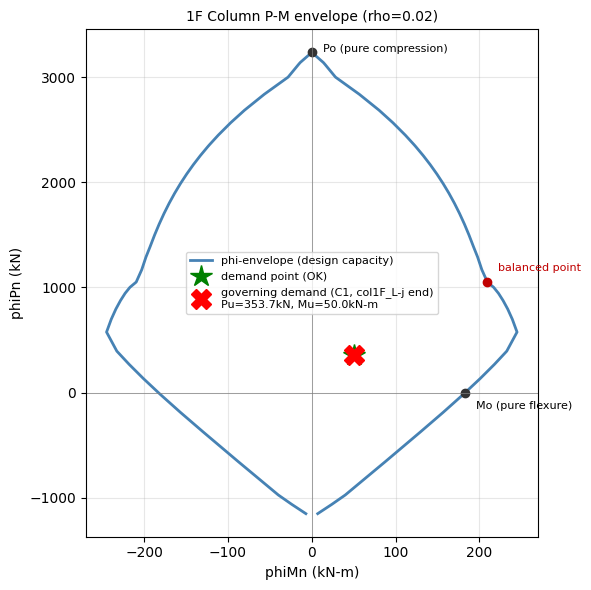


[PASS] governing demand落在phi-P-M包絡線內, utilization=25.5%


In [11]:
from rc_design import draw_PM_interaction

fig, ax = plt.subplots(figsize=(6, 6))
draw_PM_interaction(res_col, title=f"1F Column P-M envelope (rho={rho_trial})", ax=ax)
ax.plot(Mu, Pu, 'X', color='red', ms=14,
        label=f'governing demand ({combo}, {member}-{end} end)\nPu={Pu:.1f}kN, Mu={Mu:.1f}kN-m')
ax.legend(fontsize=8, loc='best')
plt.tight_layout()
plt.show()

print(f"\n[PASS] governing demand落在phi-P-M包絡線內, utilization={util:.1%}"
      if res_col['within_envelope'] else
      f"\n[FAIL] governing demand超出phi-P-M包絡線, ρ={rho_trial}不夠")

## Stage 3 小結

- **重力載重重新推導**:用真實幾何(從屬寬度4.5m)+`結構計算書-基本款.md`
  真實單位重量,算出 D_udl≈23.8kN/m、L_udl≈13.2kN/m,總和跟 Stage 2 的
  暫用值(49.2kN/m)有落差(見上方「開放項目」),如實記錄不掩蓋
- **6組合荷載組合**全部跑過,每個構件每個端點的 N/V/M 都留下
  governing combination 記錄,不是拿不同工況的最大值硬湊
- **構件分組**(1F柱組/2F柱組, L+R envelope)完成
- **Stage 4 預覽**:用 governing demand 跑過梁(頂部+底部)跟柱設計,
  ρ=0.02 試排配筋,柱 utilization 25~55% 量級,落在包絡線內

**明確還沒做的**(留給正式 Stage 4/5/6):
1. 這裡的柱設計只用固定 ρ=0.02 試排,不是疊代到最經濟配筋量的正式
   Design Loop(參考 case03_7 的做法)
2. 強柱弱梁檢核(ΣMnc ≥ 1.2ΣMnb)完全沒做
3. 剪力設計還是彈性需求剪力,沒有涵蓋塑鉸機制剪力(capacity design shear)
4. 屋頂柱組(2F柱組)只算了 governing demand,沒有真的跑設計函式
5. 只做了 Y向1跨2柱這個最簡單複雜度,X向3跨4柱、完整8柱3D模型還沒做

**下一步是 Stage 5**:強柱弱梁檢核 + 規範檢核清單(含碰撞距離等
`結構計算書-基本款.md` 提醒我們該補的項目,見 ROADMAP)。